# Computation of eigenvalues of the Laplace-Operator with homogeneous Dirichlet BC

In this notebook, we compute the eigenvalues of the Laplace operator with homogeneous Dirichlet BC.

First, we write a function that computes the system matrix.

In [1]:
"""
    HFD1D_Dirichlet(a, N)

Discretizes the Laplace-Operator for the 1D problem of length `a` 
with homogeneous Dirichlet BC using `N` segments.
"""
function HFD1D_Dirichlet(a::F, N) where F

    h = a/N

    d = -2/h^2
    s = 1/h^2

    # Note that there are N+1 grid points
    # But since we have a Dirichlet condition
    # we know that the value at f_0 and f_N
    # equals zero
    # ==> Leads to a reduced system of equations
    A = zeros(F, N-1, N-1)
    
    for i=1:N-1
        A[i, i] = d 
        
        if i < N-1
            A[i, i + 1] = s
        end
        
        if i > 1
            A[i, i - 1] = s
        end
    end

    return A
end

HFD1D_Dirichlet

## Visualization of the matrix

In [5]:
HFD1D_Dirichlet(1.0, 6)

5×5 Matrix{Float64}:
 -72.0   36.0    0.0    0.0    0.0
  36.0  -72.0   36.0    0.0    0.0
   0.0   36.0  -72.0   36.0    0.0
   0.0    0.0   36.0  -72.0   36.0
   0.0    0.0    0.0   36.0  -72.0

## Computing the eigenvalues
We compute the eigenvalues refining the grid several times in order to estimate the order of convergences.

In [2]:
using Formatting
using LinearAlgebra
using DataFrames

nvals = [10; 20; 40; 80]
a = Float64(π) # Pi is of a special data type -> convert

# Compute lowest two eigenvalues
k_1 = Float64[]
k_2 = Float64[]
hs = Float64[]

for n in nvals
    A = HFD1D_Dirichlet(a, n)
    
    # eigen() needs a dense matrix --> provide it by Matrix(A), which converts A into a dense matrix
    λ, V = eigen(A) # And now convert it to dense matrix...
    k_num = sqrt.(sort(abs.(λ)))
    
    # Save results for post-processing
    push!(hs, a/n)
    push!(k_1, k_num[1])
    push!(k_2, k_num[2])
end

# DataFrames.jl is a powerful package to manage and display data
df = DataFrame(n=nvals, h=hs, k₁=k_1, k₂=k_2)

,n,h,k₁,k₂
,Int64,Float64,Float64,Float64
1,10,0.314159,0.995893,1.96726
2,20,0.15708,0.998972,1.99179
3,40,0.0785398,0.999743,1.99794
4,80,0.0392699,0.999936,1.99949


We see that $k_1$ and $k_2$ are converging.

In [3]:
function estimate_p(h, I)
    return log((I[end-2] - I[end-1])/(I[end-1] - I[end]))/log(h[end-2]/h[end-1])
end

printfmtln("Order of convergence of k_1: {1:<10.4f}", estimate_p(hs, k_1))
printfmtln("Order of convergence of k_2: {1:<10.4f}", estimate_p(hs, k_2))

Order of convergence of k_1: 1.9996    
Order of convergence of k_2: 1.9983    


It is evident from the output, that we have quadratic convergence, that is $\mathcal O(h^2)$. This is in line with FD theory.

## Comparison with analytical eigenvalues
For the Dirichlet boundary condition, we know that
\begin{equation}
\sin(k_m x)
\end{equation}
are the eigenfunctions
with 
\begin{equation}
k_m = \frac{\pi m}{a}\quad m \in \mathbb{N}
\end{equation}
the square roots of the eigenvalues.

Let's compare all the (square roots of the) numerical eigenvalues with their analytical counterpart using a plot.

In [4]:
using Plots
using LinearAlgebra 

N = 50
a = Float64(π)

A = HFD1D_Dirichlet(a, N)
λ, V = eigen(Matrix(A))
k_num = sqrt.(sort(abs.(λ)))

k_ana = [i*π/a for i=1:N-1]
sindices = 1:N-1

1:49

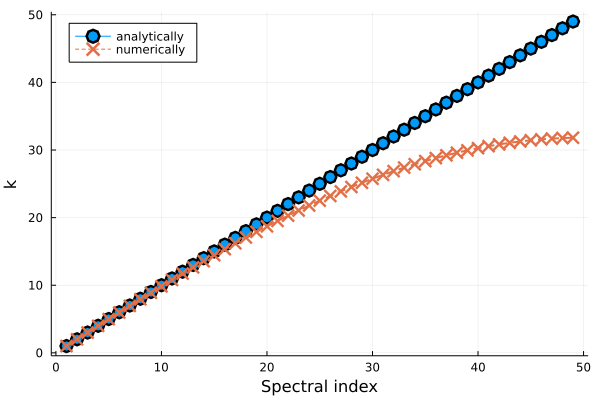

In [5]:
kwargs = Dict(:markersize=>6, :linewidth=>2, :markerstrokewidth=>3)

plt = plot(xlabel="Spectral index", ylabel="k", legend=:topleft)
plot!(plt, sindices, k_ana, label="analytically", markershape=:o, linestyle=:solid; kwargs...)
plot!(plt, sindices, k_num, label="numerically", markershape=:x, linestyle=:dash; kwargs...)

This is exactly the behavior we have predicted in chapter 3.2, when we studied the derivates of complex exponentials!

## Visualization of 1D eigenmodes with Dirichlet BC

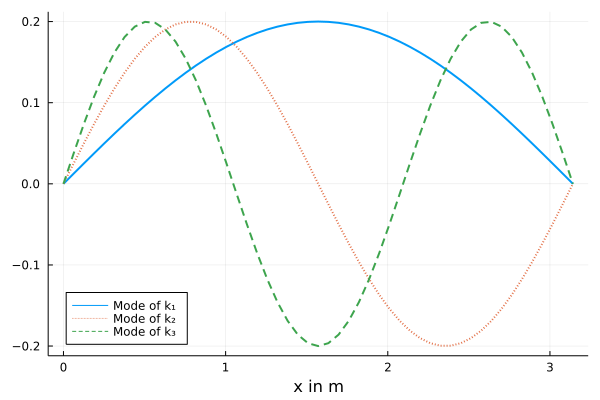

In [9]:
# Add the Dirichlet condition to the eigenfunctions
EF = vcat(zeros(1,size(V,2)),V,zeros(1,size(V,2)))

x = range(start=0, stop=a, length=length(EF[:,end]))

plt = plot(xlabel="x in m", legend=:bottomleft)

plt = plot!(plt, x, EF[:,end], label="Mode of k₁", linestyle=:solid, linewidth=2)
plt = plot!(plt, x, EF[:,end-1], label="Mode of k₂", linestyle=:dot, linewidth=2)
plt = plot!(plt, x, EF[:,end-2], label="Mode of k₃", linestyle=:dash, linewidth=2)